# Example usage

To use `mcconverge` in a project:

In [17]:
%pip install git+https://github.com/adityahnair/mcconverge.git

%pip install --force-reinstall git+https://github.com/adityahnair/mcconverge.git
import mcconverge

print(mcconverge.__version__)

  Cloning https://github.com/adityahnair/mcconverge.git to /private/var/folders/ws/2jtnzmln7y9g2hynjtfj4ks00000gn/T/pip-req-build-edi2imrz
  Running command git clone --filter=blob:none --quiet https://github.com/adityahnair/mcconverge.git /private/var/folders/ws/2jtnzmln7y9g2hynjtfj4ks00000gn/T/pip-req-build-edi2imrz
  Resolved https://github.com/adityahnair/mcconverge.git to commit 1aa006172606fe84a178c4e55055ac5c334609f0
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/adityahnair/mcconverge.git to /private/var/folders/ws/2jtnzmln7y9g2hynjtfj4ks00000gn/T/pip-req-build-gqrqx5ad
  Running command git clone --filter=blob:none --quiet https://github.com/adityahnair/mcconverge.git /private/var/folders/ws/2jtnzmln7y9g2hynjtfj4ks00000gn/T/pip-req-build-gqrqx5ad
  Resolved https://github.com/adityahnair/mcconverg

In [18]:
# Imports
%pip install numpy
%pip install matplotlib
%pip install pandas
%pip install scipy
import numpy as np
import matplotlib.pyplot as plt
from mcconverge.variables import RandomVariable, SUPPORTED_DISTRIBUTIONS
from mcconverge.simulator import MonteCarloSimulator, CostComponent, NPVModel
from mcconverge import plotting
import pandas as pd

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [19]:
# Define uncertain input variables
# CO2 price: expert estimate (min, most likely, max) — triangular is ideal here
print("Supported distributions:", SUPPORTED_DISTRIBUTIONS)
co2_price   = RandomVariable("co2_price",   "triangular", low=20,   mode=80,   high=200)
electricity = RandomVariable("electricity", "normal",     mean=0.12, std=0.03)
raw_mat     = RandomVariable("raw_material","lognormal",  mean=4.5,  std=0.3)

print(co2_price)
print(electricity)
print(raw_mat)

Supported distributions: ['normal', 'uniform', 'triangular', 'lognormal']
RandomVariable(name='co2_price', distribution='triangular', params={'low': 20, 'mode': 80, 'high': 200})
RandomVariable(name='electricity', distribution='normal', params={'mean': 0.12, 'std': 0.03})
RandomVariable(name='raw_material', distribution='lognormal', params={'mean': 4.5, 'std': 0.3})


In [20]:
# What happens with an invalid input (validation demo)
try:
    bad_rv = RandomVariable("x", "exponential", mean=1)
except ValueError as e:
    print(f"Caught expected error: {e}")

Caught expected error: Distribution 'exponential' is not supported. Choose from: ['normal', 'uniform', 'triangular', 'lognormal']


In [21]:
# Build the NPV cost model
model = NPVModel(horizon_years=20, discount_rate=0.05)

model.add_cost(CostComponent(
    name="CO2 cost",
    quantity=5.0,           # tonnes CO2 per tonne product
    unit_price=co2_price,   # €/tonne CO2 — uncertain
    escalation_rate=0.02,   # 2% annual increase
))
model.add_cost(CostComponent(
    name="Electricity",
    quantity=800,            # kWh per tonne product
    unit_price=electricity,  # €/kWh — uncertain
))
model.add_cost(CostComponent(
    name="Raw material",
    quantity=1.1,            # tonnes input per tonne output (melt loss = 10%)
    unit_price=raw_mat,      # €/tonne — uncertain
))
model.add_revenue(CostComponent(
    name="Product revenue",
    quantity=1.0,
    unit_price=500.0,        # €/tonne — fixed selling price
))

print(model)


NPVModel(horizon_years=20, costs=3, revenues=1)


In [22]:
# Run the Monte Carlo simulation
sim = MonteCarloSimulator(model=model, n_samples=50_000, seed=99)
sim.add_input(co2_price)
sim.add_input(electricity)
sim.add_input(raw_mat)

result = sim.run()
print(result)

SimulationResult(n=50000, mean=-3762.93, std=2909.00, 90% CI=[-8960.98, 668.36])


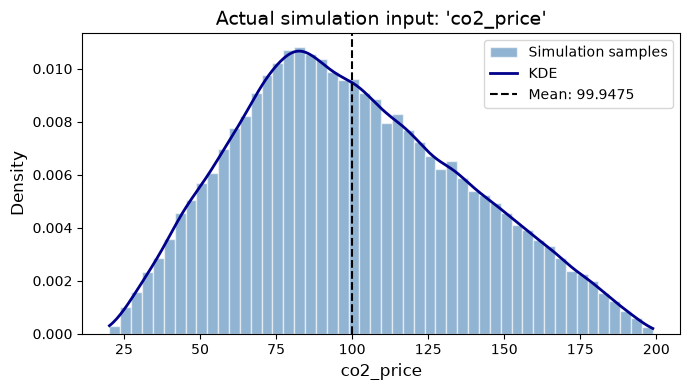

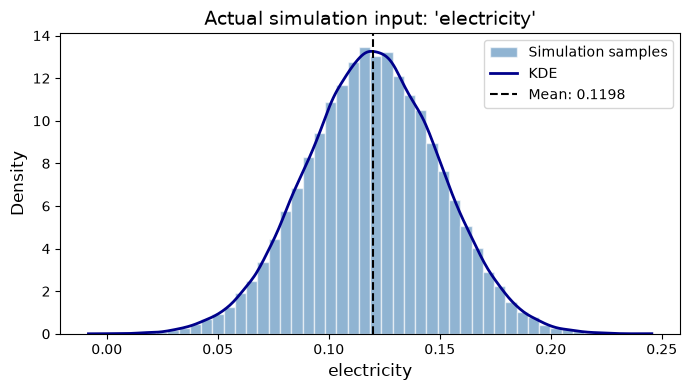

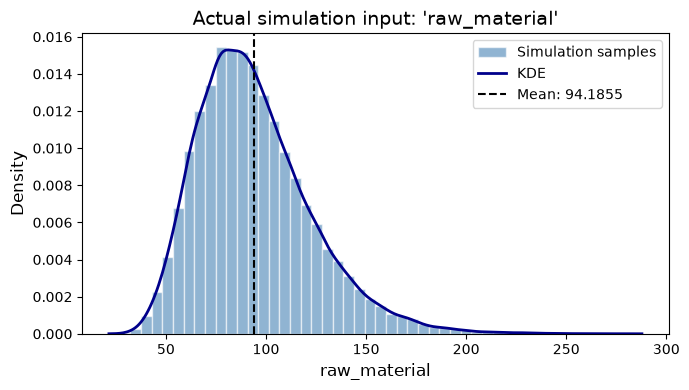

In [23]:
# Visualize simulation input samples
fig = plotting.plot_simulation_input(result, "co2_price")
plt.show()

fig = plotting.plot_simulation_input(result, "electricity")
plt.show()

fig = plotting.plot_simulation_input(result, "raw_material")
plt.show()

In [24]:
# Statistics Summary table
summary = result.summary()
df = pd.DataFrame([summary])
df.columns = ["Mean", "Std", "P5", "P95", "Min", "Max", "N"]
print(df.to_string(index=False))

        Mean         Std           P5        P95           Min         Max     N
-3762.932765 2909.004141 -8960.984903 668.359709 -13180.621608 3469.965813 50000


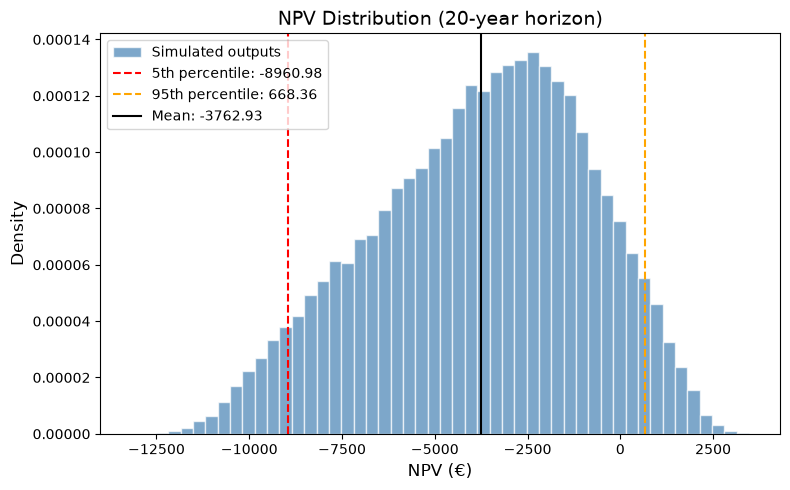

In [25]:
# Plot the output distribution
fig = plotting.plot_output_distribution(
    result,
    title="NPV Distribution (20-year horizon)",
    xlabel="NPV (€)"
)
plt.show()

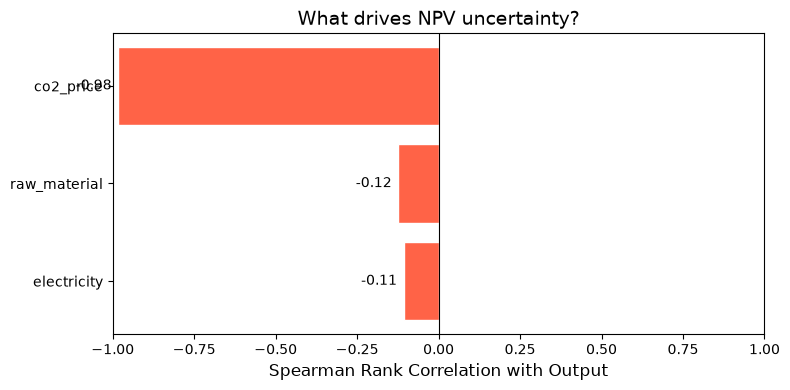

In [26]:
# Sensitivity analysis (tornado chart)
fig = plotting.plot_tornado(result, title="What drives NPV uncertainty?")
plt.show()

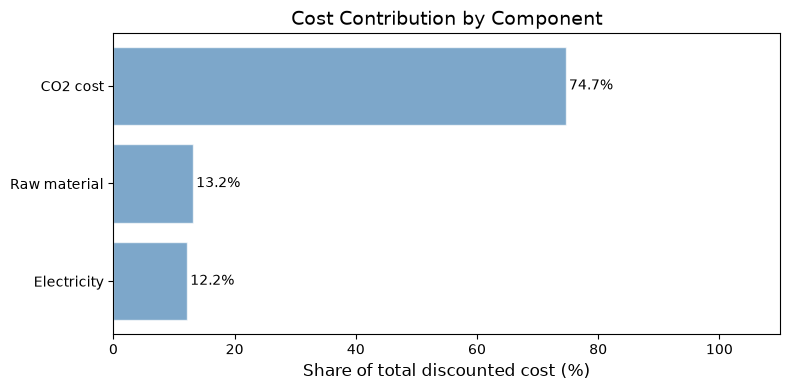

In [27]:
# Cost breakdown chart
fig = plotting.plot_cost_breakdown(result, model, title="Cost Contribution by Component")
plt.show()


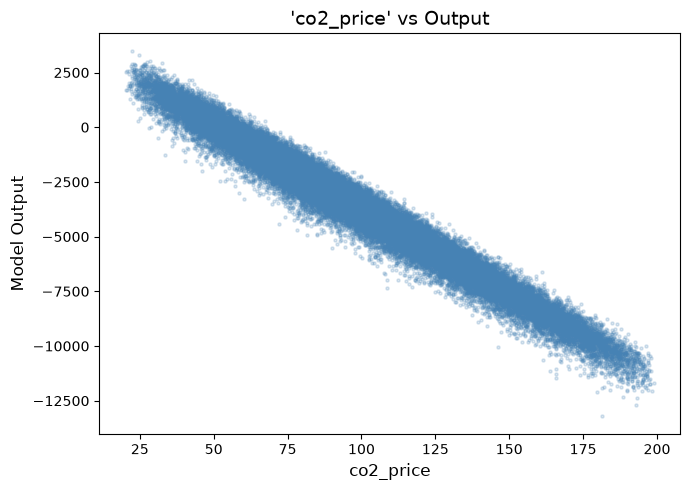

In [28]:
# Scatter plot for the most influential input
fig = plotting.plot_input_vs_output(result, "co2_price")
plt.show()

Recommended minimum N: 8322


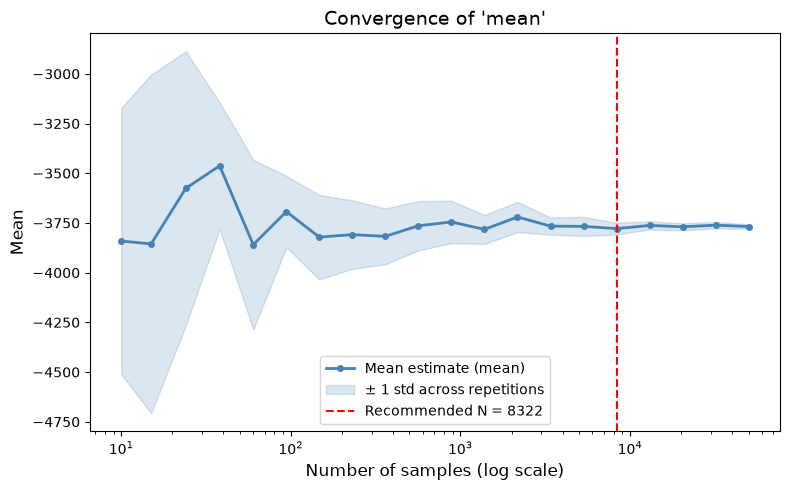

In [29]:
# Convergence study
conv = sim.run_convergence_study(metric="mean", n_repetitions=15)
print(f"Recommended minimum N: {conv.recommended_n()}")

fig = plotting.plot_convergence(conv)
plt.show()

In [30]:
# How to reproduce using the seed
sim_a = MonteCarloSimulator(model=model, n_samples=1000, seed=99)
sim_a.add_input(co2_price); sim_a.add_input(electricity); sim_a.add_input(raw_mat)

sim_b = MonteCarloSimulator(model=model, n_samples=1000, seed=99)
sim_b.add_input(co2_price); sim_b.add_input(electricity); sim_b.add_input(raw_mat)

assert np.allclose(sim_a.run().outputs, sim_b.run().outputs)
print("Reproducibility confirmed: same seed → identical results")

Reproducibility confirmed: same seed → identical results
